In [1]:
import jax.numpy as jnp
import jax
from typing import Tuple


def _normalize(
    u: jnp.ndarray, axis: int = 0, eps: float = 1e-15
) -> Tuple[jnp.ndarray, jnp.ndarray]:
    """Normalizes the values within the axis in a way that they sum up to 1.

    Parameters
    ----------
    u : jnp.ndarray
        Array to normalize
    axis : int, optional
        Axis to normalize, by default 0
    eps : float, optional
        Small value to avoid division by zero, by default 1e-15

    Returns
    -------
    normalized_u : jnp.ndarray
        Normalized array
    c : jnp.ndarray
        Normalization constant
    """
    u = jnp.clip(u, a_min=eps, a_max=None)
    c = u.sum(axis=axis)
    return u / c, c


# Helper functions for the two key filtering steps
def _condition_on(probs: jnp.ndarray, ll: jnp.ndarray) -> Tuple[jnp.ndarray, float]:
    """Condition on new emissions, given in the form of log likelihoods
    for each discrete state, while avoiding numerical underflow.

    Parameters
    ----------
    probs : jnp.ndarray
        Current state probabilities
    ll : jnp.ndarray
        Log likelihoods for each state

    Returns
    -------
    new_probs : jnp.ndarray
        Updated state probabilities
    log_norm : float
        Log normalization constant
    """
    ll_max = ll.max()
    ll_max = jnp.where(jnp.isfinite(ll_max), ll_max, 0.0)
    new_probs, norm = _normalize(probs * jnp.exp(ll - ll_max))
    log_norm = jnp.log(norm) + ll_max
    return new_probs, log_norm


@jax.jit
def filter(
    initial_distribution: jnp.ndarray,
    transition_matrix: jnp.ndarray,
    log_likelihoods: jnp.ndarray,
) -> Tuple[Tuple[float, jnp.ndarray], Tuple[jnp.ndarray, jnp.ndarray]]:
    """Filtering step.

    Parameters
    ----------
    initial_distribution : jnp.ndarray, shape (n_states,)
        Initial state distribution
    transition_matrix : jnp.ndarray, shape (n_states, n_states)
        Transition matrix
    log_likelihoods : jnp.ndarray, shape (n_time, n_states)
        Log likelihoods for each state at each time point

    Returns
    -------
    marginal_likelihood : float
    predicted_probs_next : jnp.ndarray, shape (n_states,)
        Next one-step-ahead predicted state probabilities
    causal_posterior : jnp.ndarray, shape (n_time, n_states)
        Filtered state probabilities
    predicted_probs : jnp.ndarray, shape (n_time, n_states)
        One-step-ahead predicted state probabilities
    """

    def _step(carry, ll):
        log_normalizer, predicted_probs = carry

        filtered_probs, log_norm = _condition_on(predicted_probs, ll)
        log_normalizer += log_norm
        predicted_probs_next = filtered_probs @ transition_matrix

        return (log_normalizer, predicted_probs_next), (filtered_probs, predicted_probs)

    return jax.lax.scan(_step, (0.0, initial_distribution), log_likelihoods)

In [2]:
# Simulate two-state HMM
import numpy as np
import scipy.special
import scipy.stats


def simulate_poisson_hmm(n_time: int = 100_000) -> Tuple:
    n_time = 30_000
    n_states = 2
    initial_distribution = np.array([0.5, 0.5])
    transition_matrix = np.array([[0.99, 0.01], [0.02, 0.98]])
    sampling_rate = 1000.0
    dt = 1.0 / sampling_rate
    poisson_params = np.array([100.0, 500.0]) * dt

    latent_states = np.zeros(n_time, dtype=int)
    observations = np.zeros(n_time, dtype=int)
    state_ind = np.arange(n_states)

    # Initialize the first state
    latent_states[0] = np.random.choice(state_ind, p=initial_distribution)

    # Generate the latent states sequence
    for t in range(1, n_time):
        latent_states[t] = np.random.choice(
            state_ind, p=transition_matrix[latent_states[t - 1]]
        )
        observations[t] = np.random.poisson(poisson_params[latent_states[t]])

    log_likelihoods = np.zeros((n_time, n_states))
    log_likelihoods[:, 0] = scipy.stats.poisson.logpmf(
        k=observations, mu=poisson_params[0]
    )
    log_likelihoods[:, 1] = scipy.stats.poisson.logpmf(
        k=observations, mu=poisson_params[1]
    )
    time = np.arange(n_time) / sampling_rate

    return (
        initial_distribution,
        transition_matrix,
        log_likelihoods,
        latent_states,
        observations,
        sampling_rate,
        time,
        poisson_params,
    )


(
    true_initial_distribution,
    true_transition_matrix,
    true_log_likelihoods,
    true_latent_states,
    observations,
    sampling_rate,
    time,
    poisson_params,
) = simulate_poisson_hmm(n_time=500_000)

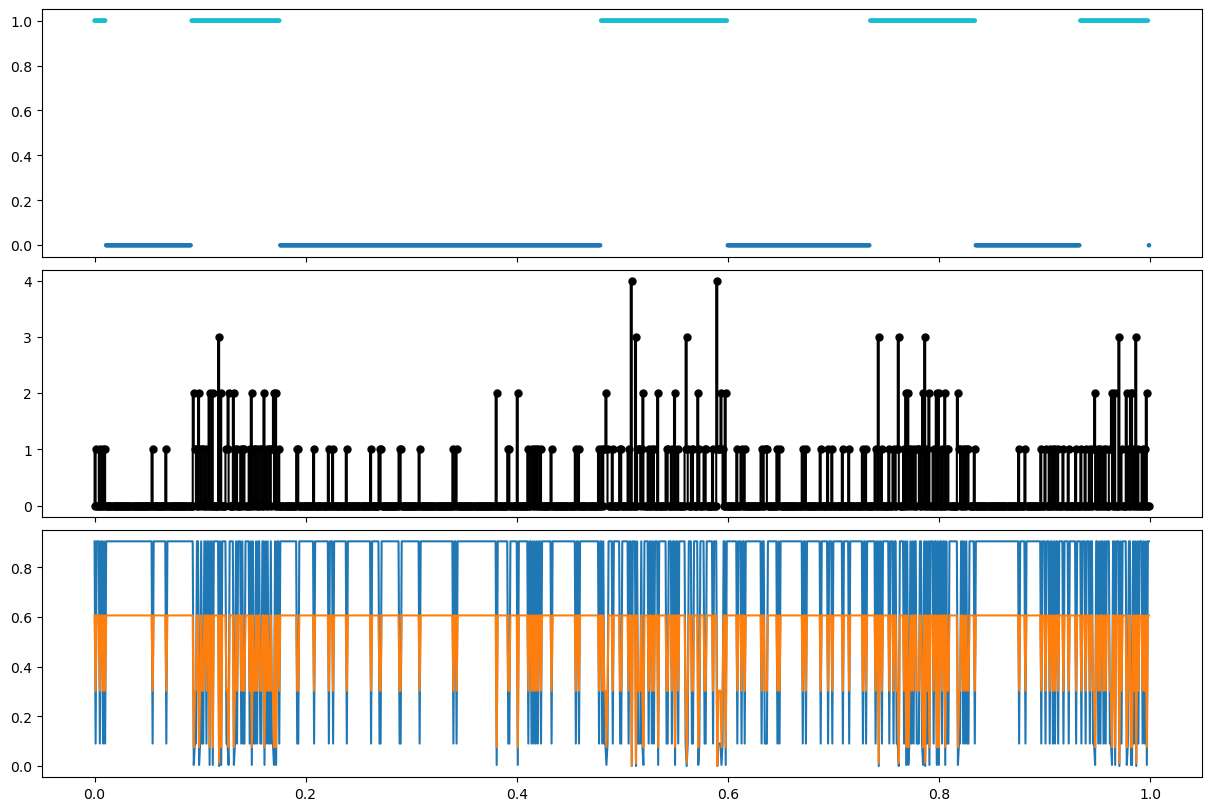

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True, sharey=False, constrained_layout=True)
time_slice = slice(0, 1_000)

axes[0].scatter(time[time_slice], true_latent_states[time_slice], c=true_latent_states[time_slice], cmap="tab10", s=5)
axes[1].step(time[time_slice], observations[time_slice], color="black", marker="o", markersize=5)
axes[2].plot(time[time_slice], np.exp(true_log_likelihoods[time_slice]))

In [4]:
observations[true_latent_states == 0].mean() * sampling_rate, observations[
    true_latent_states == 1
].mean() * sampling_rate

(98.89075963157373, 492.75953497858455)

(0.0, 1.0)

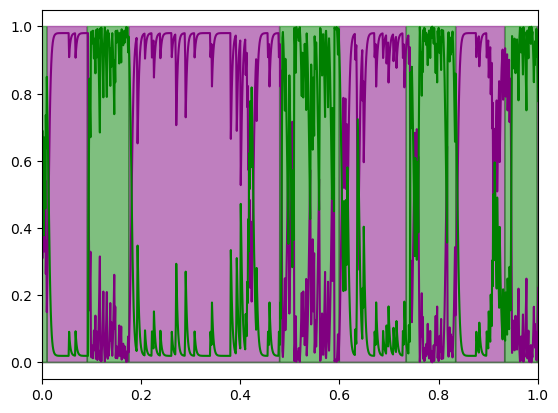

In [5]:
(marginal_likelihood, _), (filtered_probs, _) = filter(
    true_initial_distribution, true_transition_matrix, true_log_likelihoods
)

plt.fill_between(time, 0, true_latent_states == 0, color="purple", alpha=0.5)
plt.fill_between(time, 0, true_latent_states == 1, color="green", alpha=0.5)
plt.plot(time, filtered_probs[:, 0], color="purple")
plt.plot(time, filtered_probs[:, 1], color="green")
# plt.eventplot(observations, color="black")
plt.xlim((0, 1))

In [30]:
from jax.scipy.optimize import minimize
import jax.nn
import jax.numpy as jnp


@jax.jit
def centered_softmax_forward(y):
    """`softmax(x) = exp(x-c) / sum(exp(x-c))` where c is the last coordinate

    Example
    -------
    > y = np.log([2, 3, 4])
    > np.allclose(centered_softmax_forward(y), [0.2, 0.3, 0.4, 0.1])
    """
    if y.ndim == 1:
        y = jnp.append(y, 0)
    else:
        y = jnp.column_stack((y, jnp.zeros((y.shape[0],))))

    return jax.nn.softmax(y, axis=-1)


@jax.jit
def centered_softmax_inverse(y):
    """`softmax(x) = exp(x-c) / sum(exp(x-c))` where c is the last coordinate

    Example
    -------
    > y = np.asarray([0.2, 0.3, 0.4, 0.1])
    > np.allclose(np.exp(centered_softmax_inverse(y)), np.asarray([2,3,4]))
    """
    return jnp.log(y[..., :-1]) - jnp.log(y[..., [-1]])


def optimize_hmm(
    initial_distribution, transition_matrix, log_likelihoods=None, design_matrix=None,
):

    n_states = initial_distribution.size
    n_trans_params = transition_matrix.size

    flat_params_bounds = np.cumsum(
        [
            n_states - 1,
            n_trans_params - n_states,
        ]
    )

    coefficients = jnp.zeros(2)
    if design_matrix is None:
        design_matrix = jnp.ones((log_likelihoods.shape[0], n_states))

    def negative_log_likelihood(params):
        (
            transformed_initial_distribution,
            transformed_transition_matrix,
            _,
        ) = jnp.split(params, flat_params_bounds)

        initial_distribution = centered_softmax_forward(
            transformed_initial_distribution
        )

        transition_matrix = centered_softmax_forward(
            transformed_transition_matrix.reshape((n_states, n_states - 1))
        )

        # coefficients = jnp.exp(design_matrix @ coefficients)

        (marginal_likelihood, _), (_, _) = filter(
            initial_distribution, transition_matrix, log_likelihoods
        )
        return -marginal_likelihood / log_likelihoods.shape[0]

    initial_params = jnp.concatenate(
        [
            centered_softmax_inverse(initial_distribution),
            centered_softmax_inverse(transition_matrix).ravel(),
            coefficients,
        ]
    )

    results = minimize(
        fun=negative_log_likelihood,
        x0=initial_params,
        method="BFGS",
    )

    estimated_params = results.x
    (
        estimated_transformed_initial_distribution,
        estimated_transformed__transition_matrix,
        _,
    ) = jnp.split(estimated_params, flat_params_bounds)

    estimated_initial_distribution = centered_softmax_forward(
        estimated_transformed_initial_distribution
    )
    estimated_transition_matrix = centered_softmax_forward(
        estimated_transformed__transition_matrix.reshape((n_states, n_states - 1))
    )

    return estimated_initial_distribution, estimated_transition_matrix, results


estimated_initial_distribution, estimated_transition_matrix, results = optimize_hmm(
    jnp.array([0.3, 0.7]), true_transition_matrix, true_log_likelihoods
)
results.success

Array(False, dtype=bool)

In [32]:
results

OptimizeResults(x=Array([-0.8472952,  4.595177 , -3.891509 ,  0.       ,  0.       ],      dtype=float32), success=Array(False, dtype=bool), status=Array(3, dtype=int32, weak_type=True), fun=Array(0.55123043, dtype=float32), jac=Array([-2.6167199e-06, -5.7160854e-05, -3.1125784e-04,  0.0000000e+00,
        0.0000000e+00], dtype=float32), hess_inv=Array([[1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1.]], dtype=float32), nfev=Array(20, dtype=int32, weak_type=True), njev=Array(20, dtype=int32, weak_type=True), nit=Array(1, dtype=int32, weak_type=True))

In [ ]:
import optax


def fit(params: optax.Params, optimizer: optax.GradientTransformation) -> optax.Params:
    opt_state = optimizer.init(params)

    @jax.jit
    def step(params, opt_state, batch, labels):
        loss_value, grads = jax.value_and_grad(loss)(params, batch, labels)
        updates, opt_state = optimizer.update(grads, opt_state, params)
        params = optax.apply_updates(params, updates)
        return params, opt_state, loss_value

    for i, (batch, labels) in enumerate(zip(TRAINING_DATA, LABELS)):
        params, opt_state, loss_value = step(params, opt_state, batch, labels)
        if i % 100 == 0:
            print(f"step {i}, loss: {loss_value}")

    return params